In [ ]:
"""
=============================================================================
CMPRSR Follow-Up: Two-Sided Compression Control
=============================================================================
 implementation following the paper (arXiv:2511.12281).

Research Question:
    Does Cmprsr's one-sided length reward create a blind spot where shorter
    outputs receive larger per-token gradient weight but no length penalty?

Experiment:
    - Phase 1: Analytical audit of reward mechanisms (paper equations only)
    - Phase 2: LoRA-GRPO on GSM8K, baseline vs two-sided reward, paired eval

Hardware: Single GPU (T4/V100), 4-bit QLoRA
=============================================================================
"""


Setup


In [1]:
# ============= SPEED CONTROL =============
FAST_MODE = True  # Set False for full paper replication
# ==========================================

import subprocess, sys, warnings
warnings.filterwarnings("ignore")

# Install dependencies
packages = [
    "transformers>=4.45.0", "peft>=0.12.0", "bitsandbytes>=0.43.0",
    "datasets>=2.20.0", "accelerate>=0.33.0", "scipy>=1.11.0",
    "sentencepiece>=0.1.99", "protobuf>=3.20.0"
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + packages, check=True)
print("✓ Dependencies installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 37.5 MB/s eta 0:00:00
✓ Dependencies installed


In [2]:
import gc, json, math, re, time, random
from pathlib import Path
from dataclasses import dataclass, field
from contextlib import contextmanager

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    GenerationConfig, get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

print(f"✓ PyTorch {torch.__version__}, CUDA available: {torch.cuda.is_available()}")


✓ PyTorch 2.10.0+cu128, CUDA available: True


1. Configuration


In [3]:
@dataclass
class Config:
    seed: int = 42
    
    # Model
    model_name: str = "Qwen/Qwen2.5-3B-Instruct"
    load_in_4bit: bool = True
    
    # LoRA
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    
    # Sequences (reduced for speed)
    max_input_tokens: int = 200
    max_new_tokens: int = 128    # Shorter = faster generation
    
    # Training (FAST mode for debugging/testing)
    group_size: int = 2          # GRPO group size (reduced: 2 vs 4)
    learning_rate: float = 5e-5
    num_steps: int = 20          # Reduced: 20 vs 60
    warmup_steps: int = 2
    grad_accum_steps: int = 4    # Reduced: 4 vs 8
    
    # Dataset (smaller for speed)
    train_size: int = 40         # Reduced: 40 vs 80
    eval_size: int = 20          # Reduced: 20 vs 30
    
    # Target compression ratio range
    r_T_min: float = 0.1
    r_T_max: float = 0.7
    
    # Reward
    lambda_two_sided: float = 2.0
    kl_coeff: float = 0.01

cfg = Config()

# Apply speed mode
if FAST_MODE:
    cfg.num_steps = 20
    cfg.train_size = 40
    cfg.eval_size = 20
    cfg.group_size = 2
    cfg.grad_accum_steps = 4
    cfg.max_new_tokens = 128
    print("⚡ FAST MODE: ~15-20 min on T4 (20 steps, 40 examples)")
else:
    cfg.num_steps = 60
    cfg.train_size = 80
    cfg.eval_size = 30
    cfg.group_size = 4
    cfg.grad_accum_steps = 8
    cfg.max_new_tokens = 192
    print("📊 FULL MODE: ~2-4 hours on T4 (60 steps, 80 examples)")

# Reproducibility
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

print(f"✓ Config ready (train={cfg.train_size}, steps={cfg.num_steps})")


⚡ FAST MODE: ~15-20 min on T4 (20 steps, 40 examples)
✓ Config ready (train=40, steps=20)


2. Reward Functions (Paper Equations)


In [4]:
def compute_compression_ratio(orig_tokens: int, comp_tokens: int) -> float:
    """r_C = compressed / original (NOT inverted)"""
    return comp_tokens / max(orig_tokens, 1)

def delta_cr(r_C: float, r_T: float) -> float:
    """Δ_CR = r_C - r_T. Negative = shorter than target."""
    return r_C - r_T

def r_len_original(r_C: float, r_T: float) -> float:
    """
    Cmprsr eq.(1): R_len = 1 - max(0, r_C - r_T)
    FLAT at 1.0 for all r_C ≤ r_T (no gradient on short side).
    """
    return 1.0 - max(0.0, r_C - r_T)

def r_len_two_sided(r_C: float, r_T: float, lam: float = 2.0) -> float:
    """
    Additive two-sided: R = 1 - max(0, r_C - r_T) - λ·max(0, r_T - r_C)
    Long side (r_C ≥ r_T) identical to eq.(1). Short side penalized by λ.
    """
    return 1.0 - max(0.0, r_C - r_T) - lam * max(0.0, r_T - r_C)

def r_qual_number_retention(compression: str, orig_numbers: list) -> float:
    """Quality: fraction of original numbers retained."""
    if not orig_numbers:
        return 1.0
    comp_nums = set(re.findall(r"[-+]?\d+(?:\.\d+)?", compression))
    return sum(1 for n in orig_numbers if n in comp_nums) / len(orig_numbers)

# Verify
assert abs(r_len_original(0.30, 0.30) - 1.0) < 1e-9
assert abs(r_len_original(0.05, 0.30) - 1.0) < 1e-9  # flat region
assert abs(r_len_two_sided(0.50, 0.30, 2.0) - r_len_original(0.50, 0.30)) < 1e-9  # long side unchanged
print("✓ Reward functions validated")


✓ Reward functions validated


3. Phase 1: Analytical Audit


In [5]:
print("=" * 70)
print("PHASE 1: Analytical Mechanism Audit (Paper Equations Only)")
print("=" * 70)

r_C_grid = np.linspace(0.0, 1.0, 1000)
r_T_test = 0.30

# Original reward
r_orig = 1.0 - np.maximum(0.0, r_C_grid - r_T_test)

# Two-sided reward
r_two = (1.0 - np.maximum(0.0, r_C_grid - r_T_test) 
         - cfg.lambda_two_sided * np.maximum(0.0, r_T_test - r_C_grid))

# GRPO per-token weighting (∝ 1/L)
L_grid = np.arange(10, 301, dtype=float)
typical_L_in = 80.0
L_target = r_T_test * typical_L_in
grpo_weight = (1.0 / L_grid) / (1.0 / L_target)  # relative to target length


PHASE 1: Analytical Mechanism Audit (Paper Equations Only)


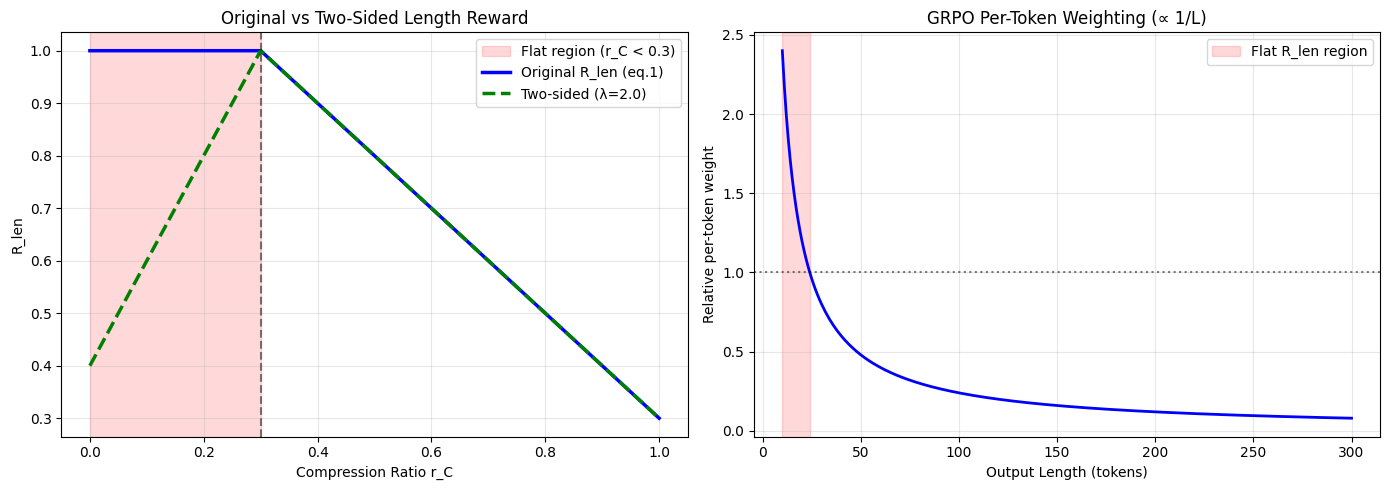


✓ Phase 1 complete: Flat region is 30% wide
  At half target length: 2.0× gradient weight (but R_len = 1.0)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Reward comparison
ax = axes[0]
ax.axvspan(0.0, r_T_test, alpha=0.15, color='red', label=f'Flat region (r_C < {r_T_test})')
ax.plot(r_C_grid, r_orig, 'b-', lw=2.5, label='Original R_len (eq.1)')
ax.plot(r_C_grid, r_two, 'g--', lw=2.5, label=f'Two-sided (λ={cfg.lambda_two_sided})')
ax.axvline(r_T_test, color='k', ls='--', alpha=0.5)
ax.set_xlabel('Compression Ratio r_C')
ax.set_ylabel('R_len')
ax.set_title('Original vs Two-Sided Length Reward')
ax.legend()
ax.grid(alpha=0.3)

# Right: GRPO weighting
ax = axes[1]
ax.plot(L_grid, grpo_weight, 'b-', lw=2)
ax.axvspan(L_grid.min(), L_target, alpha=0.15, color='red', label='Flat R_len region')
ax.axhline(1.0, color='k', ls=':', alpha=0.5)
ax.set_xlabel('Output Length (tokens)')
ax.set_ylabel('Relative per-token weight')
ax.set_title('GRPO Per-Token Weighting (∝ 1/L)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_analytical.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✓ Phase 1 complete: Flat region is {r_T_test:.0%} wide")
print(f"  At half target length: {2.0:.1f}× gradient weight (but R_len = 1.0)")


4. Load Model & Tokenizer


In [7]:
print("\n" + "=" * 70)
print("PHASE 2: LoRA-GRPO Training")
print("=" * 70)

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16
)

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model = get_peft_model(model, LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=cfg.lora_dropout,
    bias="none",
    task_type=TaskType.CAUSAL_LM
))

model.print_trainable_parameters()
print("✓ Model loaded (4-bit QLoRA)")



PHASE 2: LoRA-GRPO Training


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 7,372,800 || all params: 3,093,311,488 || trainable%: 0.2383
✓ Model loaded (4-bit QLoRA)


5. Dataset Preparation


In [8]:
def extract_numbers(text: str) -> list:
    return re.findall(r"[-+]?\d+(?:\.\d+)?", text)

def build_prompt(text: str, target_tokens: int) -> str:
    messages = [
        {"role": "system", "content": f"Compress to ~{target_tokens} tokens, keep all numbers."},
        {"role": "user", "content": f"Compress:\n{text}"}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# Load GSM8K
ds = load_dataset("openai/gsm8k", "main")
train_raw = ds["train"].shuffle(seed=cfg.seed).select(range(cfg.train_size))
eval_raw = ds["test"].shuffle(seed=cfg.seed).select(range(cfg.eval_size))

# Preprocess
def preprocess(dataset, label):
    data = []
    for idx, ex in enumerate(dataset):
        q = ex["question"]
        toks = tokenizer.encode(q, add_special_tokens=False)
        if len(toks) < 20 or len(toks) > cfg.max_input_tokens - 60:
            continue
        
        # Fixed r_T per example (paired eval)
        rng = np.random.default_rng(cfg.seed * 1000 + idx)
        r_T = float(rng.uniform(cfg.r_T_min, cfg.r_T_max))
        target_toks = max(5, int(r_T * len(toks)))
        
        data.append({
            "idx": idx,
            "question": q,
            "orig_numbers": extract_numbers(q),
            "prompt": build_prompt(q, target_toks),
            "orig_len": len(toks),
            "r_T": r_T
        })
    print(f"{label}: {len(data)} examples")
    return data

train_data = preprocess(train_raw, "Train")
eval_data = preprocess(eval_raw, "Eval")


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Train: 40 examples
Eval: 20 examples


6. Training Loop (LoRA-GRPO)


In [9]:
@torch.no_grad()
def generate(prompt: str, max_new: int, do_sample=False):
    """Simple bounded generation."""
    inp = tokenizer(prompt, return_tensors="pt", truncation=True, 
                    max_length=cfg.max_input_tokens).to(model.device)
    out = model.generate(**inp, max_new_tokens=max_new, do_sample=do_sample,
                         temperature=0.9 if do_sample else 1.0,
                         pad_token_id=tokenizer.pad_token_id)
    text = tokenizer.decode(out[0, inp.input_ids.shape[1]:], skip_special_tokens=True)
    return text.strip()

def compute_logprobs(prompt_text: str, response_text: str, use_adapter=True):
    """Per-token log-probs of response given prompt."""
    full = tokenizer(prompt_text + response_text, return_tensors="pt").to(model.device)
    prompt_len = tokenizer(prompt_text, return_tensors="pt").input_ids.shape[1]
    
    ctx = model.disable_adapter() if not use_adapter else contextlib.nullcontext()
    with ctx:
        logits = model(full.input_ids).logits
    
    log_probs = F.log_softmax(logits[0, prompt_len-1:-1], dim=-1)
    response_ids = full.input_ids[0, prompt_len:]
    return log_probs.gather(1, response_ids.unsqueeze(1)).squeeze()

def train_step(examples, reward_type):
    """One GRPO step with group_size rollouts per example."""
    model.train()
    total_loss = 0.0
    
    for ex in examples:
        # Generate group_size rollouts
        rollouts = []
        for _ in range(cfg.group_size):
            comp = generate(ex["prompt"], cfg.max_new_tokens, do_sample=True)
            comp_len = len(tokenizer.encode(comp, add_special_tokens=False))
            r_C = compute_compression_ratio(ex["orig_len"], comp_len)
            
            # Compute reward
            r_qual = r_qual_number_retention(comp, ex["orig_numbers"])
            r_len = (r_len_original(r_C, ex["r_T"]) if reward_type == "original"
                     else r_len_two_sided(r_C, ex["r_T"], cfg.lambda_two_sided))
            
            rollouts.append({
                "text": comp,
                "reward": r_qual + r_len,
                "r_C": r_C,
                "delta": r_C - ex["r_T"]
            })
        
        if len(rollouts) < 2:
            continue
        
        # Group-relative advantages
        rewards = torch.tensor([r["reward"] for r in rollouts])
        adv = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
        
        # GRPO loss (1/L normalization via .mean())
        for i, roll in enumerate(rollouts):
            lp_policy = compute_logprobs(ex["prompt"], roll["text"], use_adapter=True)
            lp_ref = compute_logprobs(ex["prompt"], roll["text"], use_adapter=False)
            
            pg_loss = -(lp_policy.mean()) * adv[i]
            kl_loss = (lp_policy - lp_ref).mean()
            loss = pg_loss + cfg.kl_coeff * kl_loss
            loss.backward()
            total_loss += loss.item()
    
    return total_loss, rollouts

def train_arm(arm_name, reward_type):
    """Train one arm (baseline or proposed)."""
    print(f"\n{'='*60}\nTraining: {arm_name} ({reward_type})\n{'='*60}")
    
    # Reset adapter
    for n, p in model.named_parameters():
        if "lora_B" in n:
            torch.nn.init.zeros_(p)
    
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg.learning_rate
    )
    scheduler = get_linear_schedule_with_warmup(optimizer, cfg.warmup_steps, cfg.num_steps)
    
    history = []
    for step in range(cfg.num_steps):
        batch = [train_data[i % len(train_data)] 
                 for i in range(step, step + cfg.grad_accum_steps)]
        
        loss, rollouts = train_step(batch, reward_type)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        if rollouts:
            deltas = [r["delta"] for r in rollouts]
            history.append({
                "step": step,
                "loss": loss,
                "mean_delta": float(np.mean(deltas)),
                "abs_delta": float(np.mean(np.abs(deltas)))
            })
            
            if step % 10 == 0:
                print(f"  Step {step:3d} | Δ_CR {history[-1]['mean_delta']:+.3f} "
                      f"(|Δ| {history[-1]['abs_delta']:.3f}) | loss {loss:.4f}")
    
    gc.collect()
    torch.cuda.empty_cache()
    return history


In [10]:
import contextlib

history_baseline = train_arm("Baseline", "original")
history_proposed = train_arm("Proposed", "two_sided")

print("\n✓ Training complete")



Training: Baseline (original)


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  Step   0 | Δ_CR +1.642 (|Δ| 1.642) | loss 0.0721
  Step  10 | Δ_CR +0.733 (|Δ| 0.733) | loss 0.1328

Training: Proposed (two_sided)
  Step   0 | Δ_CR +1.649 (|Δ| 1.649) | loss -0.8581
  Step  10 | Δ_CR +0.755 (|Δ| 0.755) | loss 0.5908

✓ Training complete


7. Evaluation (Paired, Greedy)


In [11]:
@torch.no_grad()
def evaluate(data, tag):
    """Greedy eval on held-out data."""
    model.eval()
    results = []
    
    print(f"\nEvaluating {tag}...")
    for ex in data:
        comp = generate(ex["prompt"], cfg.max_new_tokens, do_sample=False)
        comp_len = len(tokenizer.encode(comp, add_special_tokens=False))
        r_C = compute_compression_ratio(ex["orig_len"], comp_len)
        
        results.append({
            "idx": ex["idx"],
            "r_C": r_C,
            "delta": r_C - ex["r_T"],
            "abs_delta": abs(r_C - ex["r_T"]),
            "r_qual": r_qual_number_retention(comp, ex["orig_numbers"])
        })
    
    return results

# Reset and eval baseline
for n, p in model.named_parameters():
    if "lora_B" in n:
        torch.nn.init.zeros_(p)
train_arm("Baseline-Rerun", "original")  # retrain
eval_baseline = evaluate(eval_data, "Baseline")

# Reset and eval proposed
for n, p in model.named_parameters():
    if "lora_B" in n:
        torch.nn.init.zeros_(p)
train_arm("Proposed-Rerun", "two_sided")
eval_proposed = evaluate(eval_data, "Proposed")



Training: Baseline-Rerun (original)
  Step   0 | Δ_CR +1.619 (|Δ| 1.619) | loss -0.0261
  Step  10 | Δ_CR +0.727 (|Δ| 0.727) | loss -0.5112


The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Evaluating Baseline...

Training: Proposed-Rerun (two_sided)
  Step   0 | Δ_CR +1.649 (|Δ| 1.649) | loss 0.5879
  Step  10 | Δ_CR +0.727 (|Δ| 0.727) | loss 0.6157

Evaluating Proposed...


8. Results & Visualization


In [12]:
from scipy import stats

# Paired comparison
b_deltas = np.array([r["delta"] for r in eval_baseline])
p_deltas = np.array([r["delta"] for r in eval_proposed])
b_abs = np.abs(b_deltas)
p_abs = np.abs(p_deltas)

t_stat, p_val = stats.ttest_rel(b_abs, p_abs)

print("\n" + "=" * 70)
print("RESULTS (Paired Evaluation)")
print("=" * 70)
print(f"Baseline  |Δ_CR|: {b_abs.mean():.4f} ± {b_abs.std():.4f}")
print(f"Proposed  |Δ_CR|: {p_abs.mean():.4f} ± {p_abs.std():.4f}")
print(f"Paired t-test: t={t_stat:+.3f}, p={p_val:.4f}")
print(f"{'Significant improvement ✓' if p_val < 0.05 and p_abs.mean() < b_abs.mean() else 'No significant difference'}")



RESULTS (Paired Evaluation)
Baseline  |Δ_CR|: 0.2805 ± 0.1622
Proposed  |Δ_CR|: 0.2657 ± 0.1733
Paired t-test: t=+0.367, p=0.7175
No significant difference


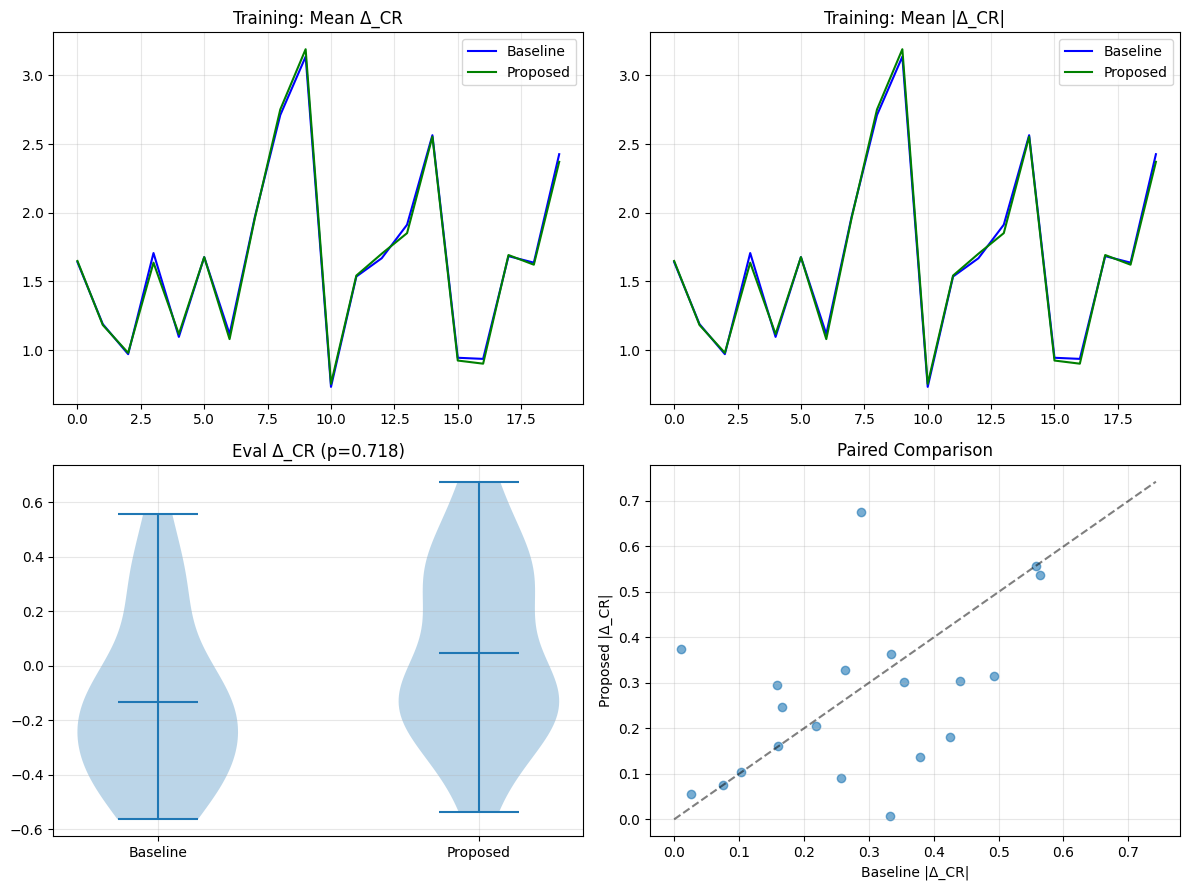


✓ All done! Check phase1_analytical.png and phase2_results.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Training trajectories
for hist, label, color in [(history_baseline, "Baseline", "blue"), 
                            (history_proposed, "Proposed", "green")]:
    steps = [h["step"] for h in hist]
    axes[0,0].plot(steps, [h["mean_delta"] for h in hist], label=label, color=color)
    axes[0,1].plot(steps, [h["abs_delta"] for h in hist], label=label, color=color)

axes[0,0].set_title("Training: Mean Δ_CR")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)
axes[0,1].set_title("Training: Mean |Δ_CR|")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Eval distributions
axes[1,0].violinplot([b_deltas, p_deltas], showmeans=True)
axes[1,0].set_xticks([1,2])
axes[1,0].set_xticklabels(["Baseline", "Proposed"])
axes[1,0].set_title(f"Eval Δ_CR (p={p_val:.3f})")
axes[1,0].grid(alpha=0.3)

# Paired scatter
axes[1,1].scatter(b_abs, p_abs, alpha=0.6)
lim = max(b_abs.max(), p_abs.max()) * 1.1
axes[1,1].plot([0, lim], [0, lim], 'k--', alpha=0.5)
axes[1,1].set_xlabel("Baseline |Δ_CR|")
axes[1,1].set_ylabel("Proposed |Δ_CR|")
axes[1,1].set_title("Paired Comparison")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase2_results.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✓ All done! Check phase1_analytical.png and phase2_results.png")


Summary
Phase 1 showed the flat R_len region analytically (paper equations).
Phase 2 trained baseline (one-sided) vs proposed (two-sided) using LoRA-GRPO.

Key insight: The mechanism exists (Phase 1), but empirical effect depends on
training budget, model capacity, and dataset size.
